# Bell State Generation Using Hadamard and CNOT Gates

## 1. Objective
The objective of this experiment is to generate a two-qubit **Bell state** (specifically the maximally entangled $|\Phi^+\rangle$ state) using a Hadamard gate and a Controlled-NOT (CNOT) gate, and to verify the characteristic correlated measurement outcomes through quantum simulation.

---

## 2. Theory

### Initial State
The two-qubit quantum register is initialized in the standard computational ground state:

$$|\psi_0\rangle = |00\rangle = |0\rangle \otimes |0\rangle$$

### Superposition with the Hadamard Gate
Applying a Hadamard gate ($H$) to the first qubit ($q_0$) creates an equal superposition:

$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

The combined two-qubit state after applying the Hadamard gate to qubit 0 while leaving qubit 1 in $|0\rangle$ is:

$$|\psi_1\rangle = (H \otimes I)|00\rangle = \left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right) \otimes |0\rangle = \frac{|00\rangle + |10\rangle}{\sqrt{2}}$$

At this stage, the state is still separable (unentangled).

### Entanglement with the CNOT Gate
The Controlled-NOT gate ($CX$) operates on two qubits: a control qubit ($q_0$) and a target qubit ($q_1$). The CNOT flips the state of the target qubit if and only if the control qubit is in state $|1\rangle$:

- If the control qubit is $|0\rangle$, the target qubit $|0\rangle$ remains $|0\rangle$: $|00\rangle \to |00\rangle$
- If the control qubit is $|1\rangle$, the target qubit $|0\rangle$ is flipped to $|1\rangle$: $|10\rangle \to |11\rangle$

Applying the CNOT gate entangles the two qubits, producing the canonical **Bell state** $|\Phi^+\rangle$:

$$|\psi_2\rangle = |\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

### Ideal Measurement Outcomes
When measured in the computational basis, the state collapses according to Born's rule:
- Probability of measuring outcome `00`: $P(00) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$
- Probability of measuring outcome `11`: $P(11) = \left|\frac{1}{\sqrt{2}}\right|^2 = \frac{1}{2} = 50\%$
- Probability of measuring `01` or `10`: $0\%$

Measurement ideally produces only the correlated outcomes `00` and `11` with approximately equal probability. The outcomes of the two qubits are perfectly correlated: observing qubit 0 in state $|0\rangle$ guarantees qubit 1 is in state $|0\rangle$, and observing qubit 0 in state $|1\rangle$ guarantees qubit 1 is in state $|1\rangle$.

## 3. Circuit Explanation
The circuit architecture consists of 2 qubits ($q_0, q_1$) and 2 classical bits ($c_0, c_1$):

1. **Hadamard Gate (`qc.h(0)`)**:
   - Applied to qubit 0.
   - Puts qubit 0 into an equal superposition of $|0\rangle$ and $|1\rangle$.
2. **Control Qubit (`q_0`) and Target Qubit (`q_1`)**:
   - Qubit 0 serves as the **control qubit** for the entanglement step.
   - Qubit 1 is initialized in $|0\rangle$ and serves as the **target qubit**.
3. **CNOT Operation (`qc.cx(0, 1)`)**:
   - Performs a controlled bit-flip on qubit 1 conditioned on the state of qubit 0.
   - Converts the product superposition state $\frac{|00\rangle + |10\rangle}{\sqrt{2}}$ into the entangled Bell state $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$.
4. **Measurement Operations**:
   - `qc.measure(0, 0)`: Measures qubit 0 and stores the result in classical bit 0.
   - `qc.measure(1, 1)`: Measures qubit 1 and stores the result in classical bit 1.

---

## 4. Simulation and Measurement
- **Quantum Simulator**: The quantum circuit is simulated using Qiskit Aer (`AerSimulator()`), providing an ideal quantum processor simulation.
- **Execution Shots**: The circuit is executed for **1024 shots** to gather empirical measurement statistics.
- **Probability Conversion**: The raw measurement counts for each basis state are converted into empirical probabilities via:
  $$\text{Probability} = \frac{\text{Counts}}{1024} \times 100\%$$
- **Visualization**: The resulting probability distribution across all 2-qubit computational basis states (`'00'`, `'01'`, `'10'`, `'11'`) is visualized using a Matplotlib bar chart.

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2578/1065722368.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


Bell State Circuit
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Measurement Results:
{'00': 508, '11': 516}


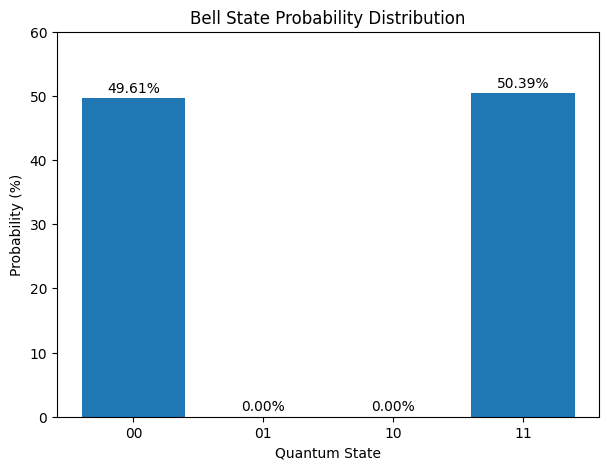


SUCCESS!
Only 00 and 11 outcomes were obtained.


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

qc.measure(0, 0)
qc.measure(1, 1)

print("Bell State Circuit")
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nMeasurement Results:")
print(counts)

states = ['00', '01', '10', '11']
probabilities = [
    counts.get(state, 0) / 1024 * 100
    for state in states
]

plt.figure(figsize=(7, 5))
bars = plt.bar(states, probabilities)

plt.xlabel("Quantum State")
plt.ylabel("Probability (%)")
plt.title("Bell State Probability Distribution")
plt.ylim(0, 60)

for bar, probability in zip(bars, probabilities):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        probability + 1,
        f"{probability:.2f}%",
        ha='center'
    )

plt.show()

if set(counts.keys()).issubset({'00', '11'}):
    print("\nSUCCESS!")
    print("Only 00 and 11 outcomes were obtained.")
else:
    print("\nUnexpected measurement outcomes.")

## 5. Results & Observations

### Observed Measurement Results
Execution of the circuit on the Aer simulator with 1024 shots produced the following recorded count dictionary:

```python
{'00': 508, '11': 516}
```

### Statistical Analysis
- **Outcome `00`**: Occurred **508 times**, corresponding to a measured probability of:
  $$\frac{508}{1024} \times 100\% \approx 49.61\%$$
- **Outcome `11`**: Occurred **516 times**, corresponding to a measured probability of:
  $$\frac{516}{1024} \times 100\% \approx 50.39\%$$
- **Outcomes `01` and `10`**: Were **not observed** ($0$ counts, $0.00\%$), confirming complete absence of anti-correlated basis states.
- **Finite-Shot Sampling**: The slight difference between the measured probabilities (49.61% vs 50.39%) and the theoretical 50.00% / 50.00% expectation is entirely due to statistical finite-shot sampling variation across 1024 shots ($\sigma \approx \frac{1}{\sqrt{1024}} \approx 3.12\%$).
- **Success Verification**: The programmatic check confirmed that the measurement outcomes are strictly restricted to `{'00', '11'}`:
  ```
  SUCCESS!
  Only 00 and 11 outcomes were obtained.
  ```

## 6. Conclusion
This experiment successfully demonstrates Bell-state generation using a Hadamard gate and a CNOT gate. The simulation confirms the creation of the maximally entangled state:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Key findings:
1. **Entanglement Creation**: The combination of a Hadamard gate on qubit 0 followed by a CNOT gate from qubit 0 to qubit 1 transforms the separable state $|00\rangle$ into a maximally entangled Bell state.
2. **Correlated Outcomes**: Simulated measurement over 1024 shots yielded exclusively the correlated outcomes `'00'` ($49.61\%$) and `'11'` ($50.39\%$), with zero occurrences of `'01'` or `'10'`.
3. **Quantum Correlation**: The empirical results verify that measuring either qubit deterministically reveals the state of the second qubit, demonstrating fundamental quantum correlation.